In [1]:
# load package
suppressMessages(suppressWarnings({
    library(CytoTRACE2)
}))

In [2]:
N4 <- readRDS('../3.subset_glia/N4_glia.rds')
T1 <- readRDS('../3.subset_glia/T1_glia.rds')
adult_brain <- readRDS('../3.subset_glia/adult_brain_glia.rds')
adult_nt <- readRDS('../3.subset_glia/adult_nt_glia.rds')

In [3]:
# load amphioxus to mouse RBH
Bflo2Mmus <- read.delim('/mnt/data01/yuanzhen/01.Vertebrate_cell_evo/02.gene_relationships/run5/results/Ortho_pipeline/OrthoFinder/RBH_results/RBH.Bflo.Mmus.tsv', header = T)
Bflo2Mmus$Bflo <- gsub('_', '-', Bflo2Mmus$Bflo)
Bflo2Mmus$Mmus <- gsub('_', '-', Bflo2Mmus$Mmus)

In [4]:
?plotData

In [27]:
# get results
run_cytotrace <- function(data, label){
    # extract information
    data <- list(expression_data = as.data.frame(LayerData(data, layer = 'counts')), 
             annotation = data@meta.data[, "celltype", drop = FALSE])
    # retain only RBH genes between amphioxus and mouse, then replace name to mouse
    data$expression_data <- data$expression_data[rownames(data$expression_data) %in% Bflo2Mmus$Bflo, ] 
    rownames(data$expression_data) <- Bflo2Mmus[match(rownames(data$expression_data), Bflo2Mmus$Bflo), 'Mmus']
    
    # running CytoTRACE 2 main function - cytotrace2 - with default parameters
    cytotrace2_result <- cytotrace2(data$expression_data, species = "mouse", seed = 42)

    # generate prediction and phenotype association plots with plotData function
    plots <- plotData(cytotrace2_result = cytotrace2_result, 
                  annotation = data$annotation,
                  expression_data = data$expression_data
                  )
    lapply(names(plots), FUN = function(p){
        ggsave(filename = paste0(label, '.', p, '.pdf'), plot = plots[[p]], width = 7, height = 8)
    })
    return(cytotrace2_result)
}


In [16]:
N4_res <- run_cytotrace(N4, 'N4')

cytotrace2: Started loading data

Dataset contains 5051 genes and 4214 cells.

The passed subsample size is greater than the number of cells in dataset.
Now setting subsample size to 4214

cytotrace2: Running on 1 subsample(s) approximately of length 4214

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

4448 input genes mapped to model genes.

Warning message in preprocessData(dt, species):
“The number of input genes mapped to the model is too low. Please verify the input species is correct.
In case of a correct species input, be advised that model performance might be compromised due to gene space differences.”
cytotrace2: Started prediction.

This section will run using  36 / 72 core(s).

cytotrace2: Started postprocessing.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 5 sub-sample(s) of approximately 843 cells each using 5 / 72 core(s).

Number of cores for KNN: 36


[[1]]
[1] "N4.CytoTRACE2_UMAP.pdf"

[[2]]
[1] "N4.CytoTRACE2_Potency_UMAP.pdf"

[[3]]
[1] "N4.CytoTRACE2_Relative_UMAP.pdf"

[[4]]
[1] "N4.Phenotype_UMAP.pdf"

[[5]]
[1] "N4.CytoTRACE2_Boxplot_byPheno.pdf"

In [17]:
T1_res <- run_cytotrace(T1, 'T1')

cytotrace2: Started loading data

Dataset contains 5059 genes and 4829 cells.

The passed subsample size is greater than the number of cells in dataset.
Now setting subsample size to 4829

cytotrace2: Running on 1 subsample(s) approximately of length 4829

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

4456 input genes mapped to model genes.

Warning message in preprocessData(dt, species):
“The number of input genes mapped to the model is too low. Please verify the input species is correct.
In case of a correct species input, be advised that model performance might be compromised due to gene space differences.”
cytotrace2: Started prediction.

This section will run using  36 / 72 core(s).

cytotrace2: Started postprocessing.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 5 sub-sample(s) of approximately 966 cells each using 5 / 72 core(s).

Number of cores for KNN: 36


[[1]]
[1] "T1.CytoTRACE2_UMAP.pdf"

[[2]]
[1] "T1.CytoTRACE2_Potency_UMAP.pdf"

[[3]]
[1] "T1.CytoTRACE2_Relative_UMAP.pdf"

[[4]]
[1] "T1.Phenotype_UMAP.pdf"

[[5]]
[1] "T1.CytoTRACE2_Boxplot_byPheno.pdf"

In [18]:
adult_brain_res <- run_cytotrace(adult_brain, 'adult_brain')

cytotrace2: Started loading data

Dataset contains 5067 genes and 1861 cells.

The passed subsample size is greater than the number of cells in dataset.
Now setting subsample size to 1861

cytotrace2: Running on 1 subsample(s) approximately of length 1861

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

4459 input genes mapped to model genes.

Warning message in preprocessData(dt, species):
“The number of input genes mapped to the model is too low. Please verify the input species is correct.
In case of a correct species input, be advised that model performance might be compromised due to gene space differences.”
cytotrace2: Started prediction.

This section will run using  36 / 72 core(s).

cytotrace2: Started postprocessing.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 2 sub-sample(s) of approximately 930 cells each using 2 / 72 core(s).

Number of cores for KNN: 36


[[1]]
[1] "adult_brain.CytoTRACE2_UMAP.pdf"

[[2]]
[1] "adult_brain.CytoTRACE2_Potency_UMAP.pdf"

[[3]]
[1] "adult_brain.CytoTRACE2_Relative_UMAP.pdf"

[[4]]
[1] "adult_brain.Phenotype_UMAP.pdf"

[[5]]
[1] "adult_brain.CytoTRACE2_Boxplot_byPheno.pdf"

In [20]:
adult_nt_res <- run_cytotrace(adult_nt, 'adult_nt')

cytotrace2: Started loading data

Dataset contains 5059 genes and 3159 cells.

The passed subsample size is greater than the number of cells in dataset.
Now setting subsample size to 3159

cytotrace2: Running on 1 subsample(s) approximately of length 3159

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

4456 input genes mapped to model genes.

Warning message in preprocessData(dt, species):
“The number of input genes mapped to the model is too low. Please verify the input species is correct.
In case of a correct species input, be advised that model performance might be compromised due to gene space differences.”
cytotrace2: Started prediction.

This section will run using  36 / 72 core(s).

cytotrace2: Started postprocessing.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 4 sub-sample(s) of approximately 790 cells each using 4 / 72 core(s).

Number of cores for KNN: 36


[[1]]
[1] "adult_nt.CytoTRACE2_UMAP.pdf"

[[2]]
[1] "adult_nt.CytoTRACE2_Potency_UMAP.pdf"

[[3]]
[1] "adult_nt.CytoTRACE2_Relative_UMAP.pdf"

[[4]]
[1] "adult_nt.Phenotype_UMAP.pdf"

[[5]]
[1] "adult_nt.CytoTRACE2_Boxplot_byPheno.pdf"

In [31]:
adult <- merge(adult_brain, adult_nt)
adult <- JoinLayers(adult)
adult_res <- run_cytotrace(adult, 'adult')

cytotrace2: Started loading data

Dataset contains 5076 genes and 5020 cells.

The passed subsample size is greater than the number of cells in dataset.
Now setting subsample size to 5020

cytotrace2: Running on 1 subsample(s) approximately of length 5020

cytotrace2: Started running on subsample(s). This will take a few minutes.

cytotrace2: Started preprocessing.

4464 input genes mapped to model genes.

Warning message in preprocessData(dt, species):
“The number of input genes mapped to the model is too low. Please verify the input species is correct.
In case of a correct species input, be advised that model performance might be compromised due to gene space differences.”
cytotrace2: Started prediction.

This section will run using  36 / 72 core(s).

cytotrace2: Started postprocessing.

cytotrace2: Running with fast mode (subsamples are processed in parallel)

This section will run on 6 sub-sample(s) of approximately 837 cells each using 6 / 72 core(s).

Number of cores for KNN: 36


[[1]]
[1] "adult.CytoTRACE2_UMAP.pdf"

[[2]]
[1] "adult.CytoTRACE2_Potency_UMAP.pdf"

[[3]]
[1] "adult.CytoTRACE2_Relative_UMAP.pdf"

[[4]]
[1] "adult.Phenotype_UMAP.pdf"

[[5]]
[1] "adult.CytoTRACE2_Boxplot_byPheno.pdf"

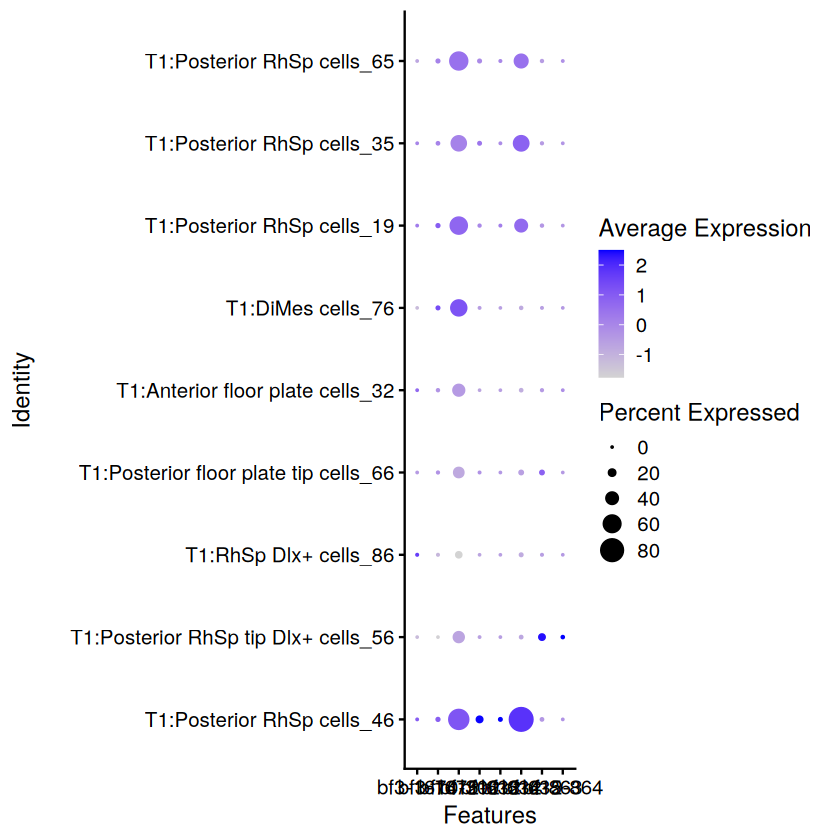

In [3]:
DotPlot(T1, features = c('bf3-1674', 'bf3-1675', 'bf10-300','bf12-633','bf12-634', 'bf12-635', 'bf12-863', 'bf12-864'), cluster.idents = T)

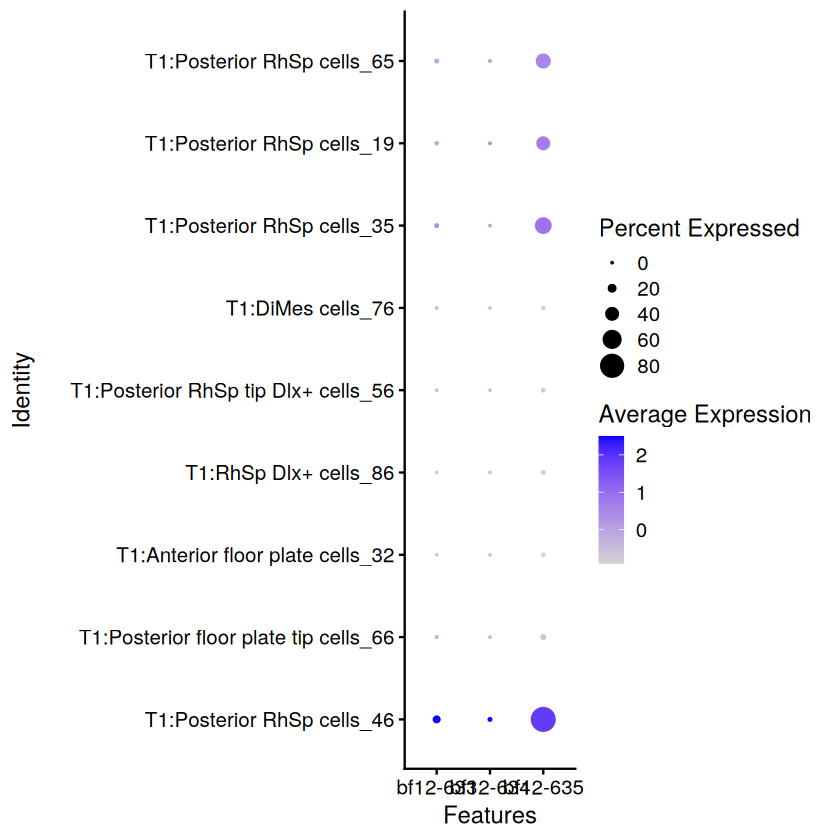

In [34]:
DotPlot(T1, features = c('bf12-633', 'bf12-634', 'bf12-635'), cluster.idents = T)

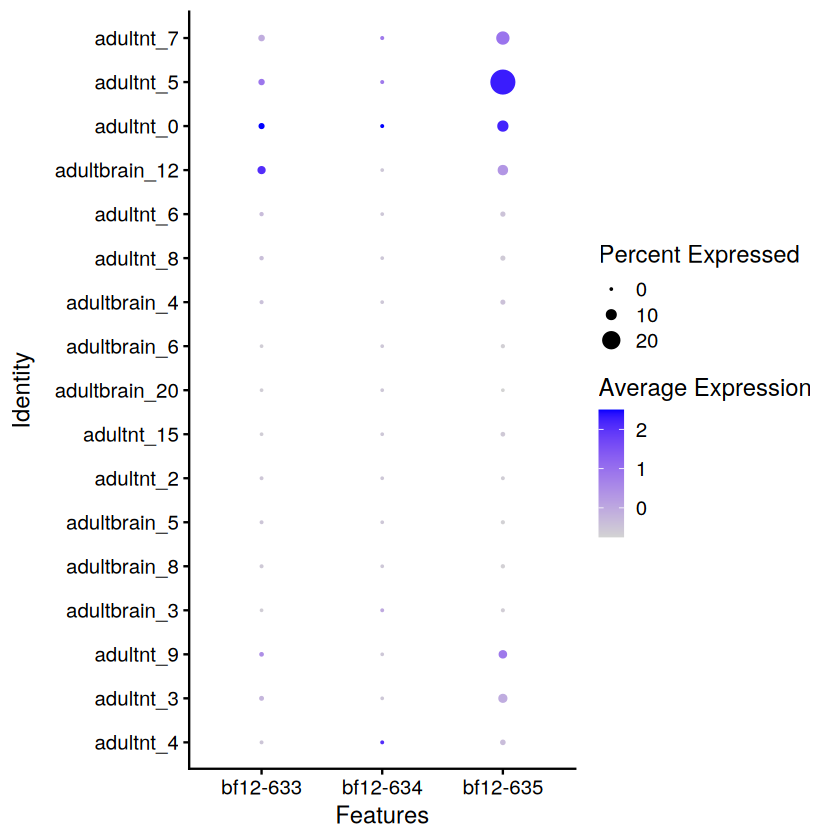

In [35]:
DotPlot(adult, features = c('bf12-633', 'bf12-634', 'bf12-635'), cluster.idents = T)